In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
# This is CRITICAL - it changes to where your files are
%cd '/content/drive/My Drive/data'

# Verify we're in the right place
import os
print("Current directory:", os.getcwd())
print("\nFirst 5 federalist files:")
files = [f for f in os.listdir('.') if f.startswith('federalist_') and f != 'federalist.txt']
print(files[:5])
print(f"\nTotal federalist files: {len(files)}")

/content/drive/My Drive/data
Current directory: /content/drive/My Drive/data

First 5 federalist files:
['federalist_11.txt', 'federalist_17.txt', 'federalist_1.txt', 'federalist_25.txt', 'federalist_18.txt']

Total federalist files: 85


Loading files...

Loading Madison papers...
Loaded: federalist_10.txt
Loaded: federalist_14.txt
Loaded: federalist_37.txt
Loaded: federalist_38.txt
Loaded: federalist_39.txt
Loaded: federalist_40.txt
Loaded: federalist_41.txt
Loaded: federalist_42.txt
Loaded: federalist_43.txt
Loaded: federalist_44.txt
Loaded: federalist_45.txt
Loaded: federalist_46.txt
Loaded: federalist_47.txt
Loaded: federalist_48.txt
   -> 236,304 characters loaded

Loading Hamilton papers...
Loaded: federalist_1.txt
Loaded: federalist_6.txt
Loaded: federalist_7.txt
Loaded: federalist_8.txt
Loaded: federalist_9.txt
Loaded: federalist_11.txt
Loaded: federalist_12.txt
Loaded: federalist_13.txt
Loaded: federalist_15.txt
Loaded: federalist_16.txt
Loaded: federalist_17.txt
Loaded: federalist_21.txt
Loaded: federalist_22.txt
Loaded: federalist_23.txt
Loaded: federalist_24.txt
Loaded: federalist_25.txt
Loaded: federalist_26.txt
Loaded: federalist_27.txt
Loaded: federalist_28.txt
Loaded: federalist_29.txt
Loaded: federalis

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Madison     : 39,106 tokens
Hamilton    : 113,974 tokens
Jay         : 6,177 tokens
Shared      : 5,736 tokens
Disputed    : 24,332 tokens
TestCase    : 2,326 tokens
WORD LENGTH DISTRIBUTIONS

Analyzing Madison...
   Total words: 39,106
   Average word length: 4.89
   Most common length: 2

Analyzing Hamilton...
   Total words: 113,974
   Average word length: 4.79
   Most common length: 2

Analyzing Jay...
   Total words: 6,177
   Average word length: 4.90
   Most common length: 2

Analyzing Shared...
   Total words: 5,736
   Average word length: 5.06
   Most common length: 3

Analyzing Disputed...
   Total words: 24,332
   Average word length: 4.86
   Most common length: 2

Analyzing TestCase...
   Total words: 2,326
   Average word length: 4.73
   Most common length: 2

Processing Hamilton...
   Total tokens: 127,314
   Alphabetic tokens: 114,208


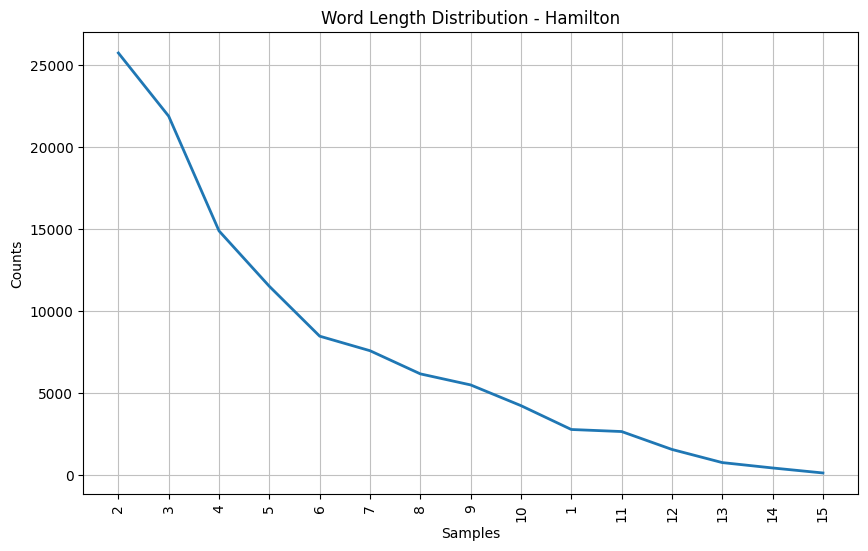


Processing Madison...
   Total tokens: 43,824
   Alphabetic tokens: 39,162


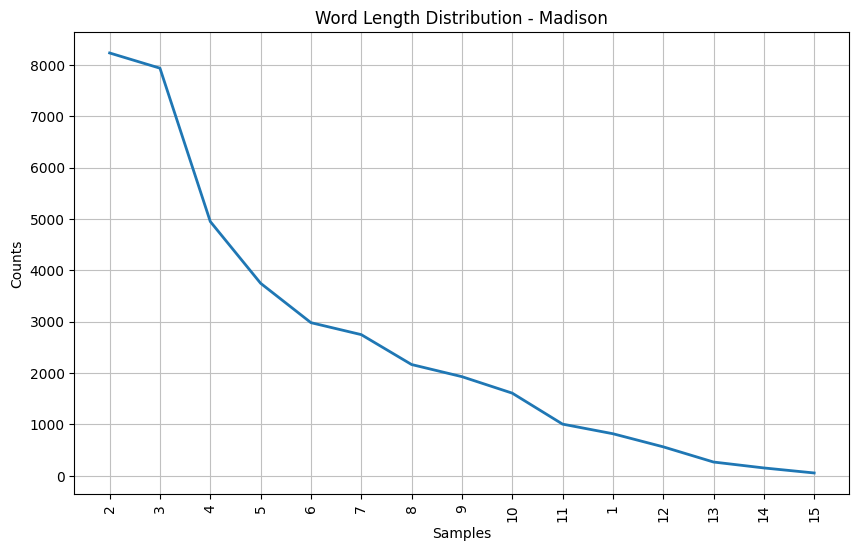


Processing Disputed...
   Total tokens: 27,164
   Alphabetic tokens: 24,385


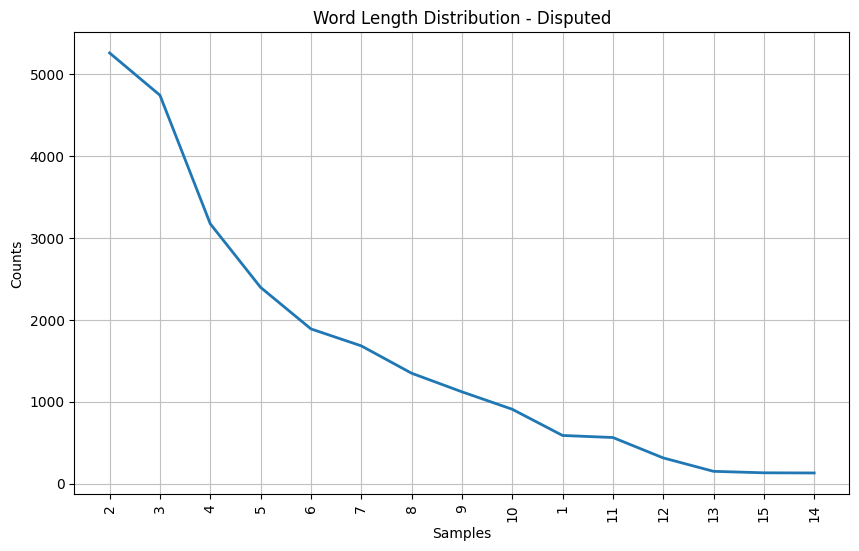


Processing Jay...
   Total tokens: 6,901
   Alphabetic tokens: 6,186


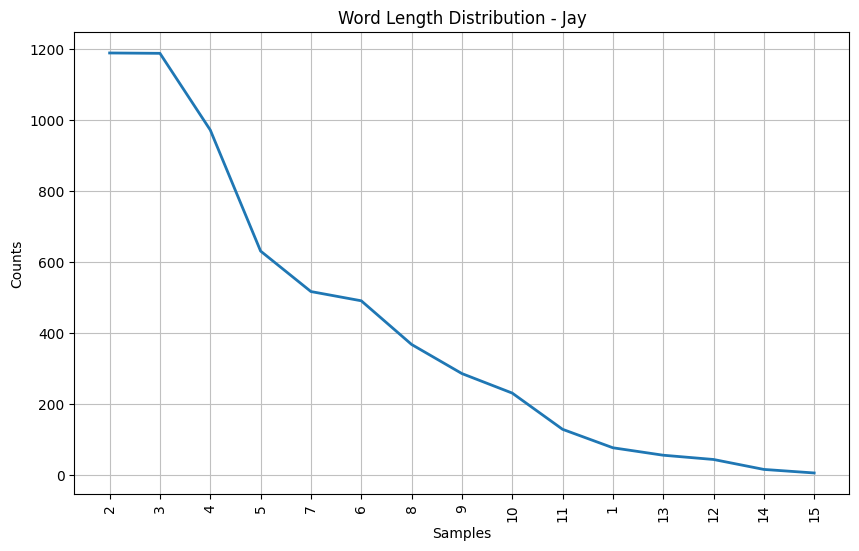


Processing Shared...
   Total tokens: 6,583
   Alphabetic tokens: 5,753


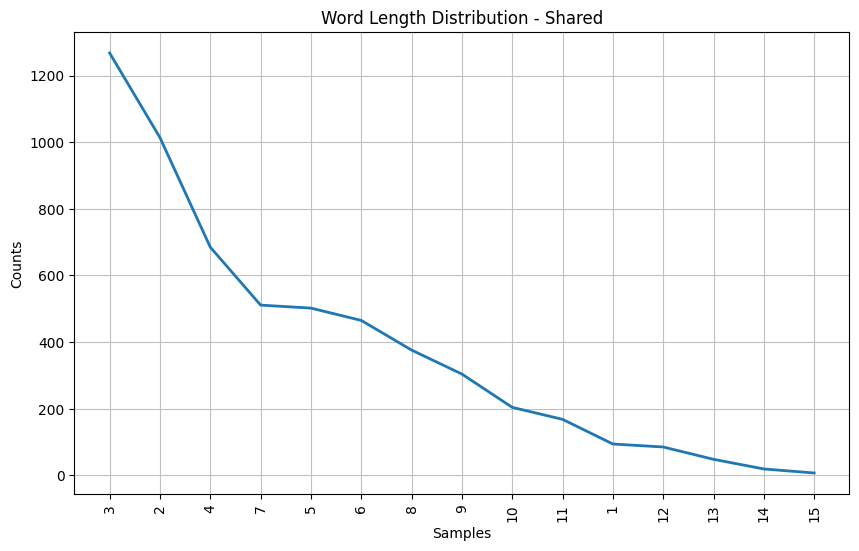

COMPARISON: All Authors Together


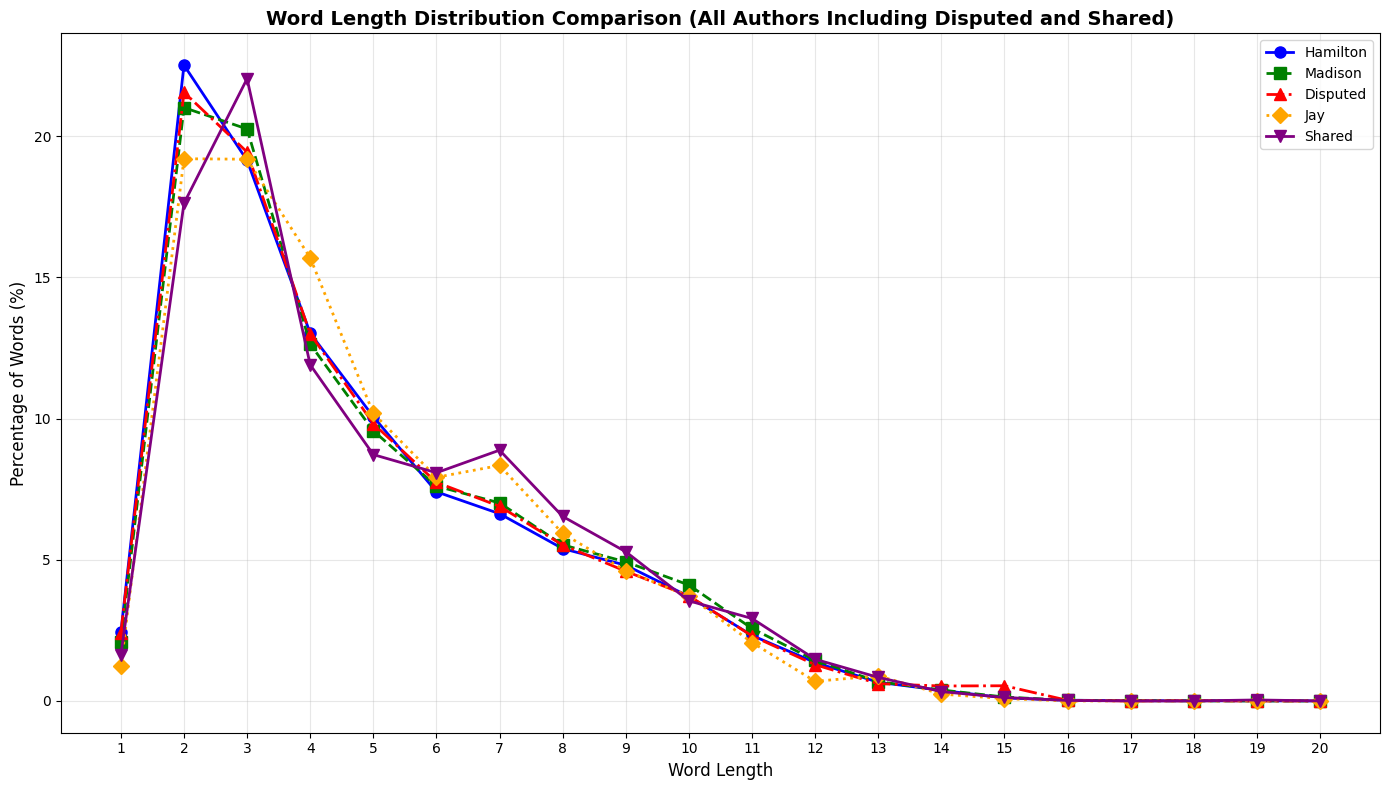

STATISTICAL SUMMARY

Hamilton:
   Total Words: 114,208
   Unique Words: 7,841
   Avg Word Length: 4.8
   Most Common Length: 2
   Type-Token Ratio: 0.069

Madison:
   Total Words: 39,162
   Unique Words: 4,655
   Avg Word Length: 4.9
   Most Common Length: 2
   Type-Token Ratio: 0.119

Disputed:
   Total Words: 24,385
   Unique Words: 3,266
   Avg Word Length: 4.87
   Most Common Length: 2
   Type-Token Ratio: 0.134

Jay:
   Total Words: 6,186
   Unique Words: 1,543
   Avg Word Length: 4.9
   Most Common Length: 2
   Type-Token Ratio: 0.249

Shared:
   Total Words: 5,753
   Unique Words: 1,725
   Avg Word Length: 5.08
   Most Common Length: 3
   Type-Token Ratio: 0.3


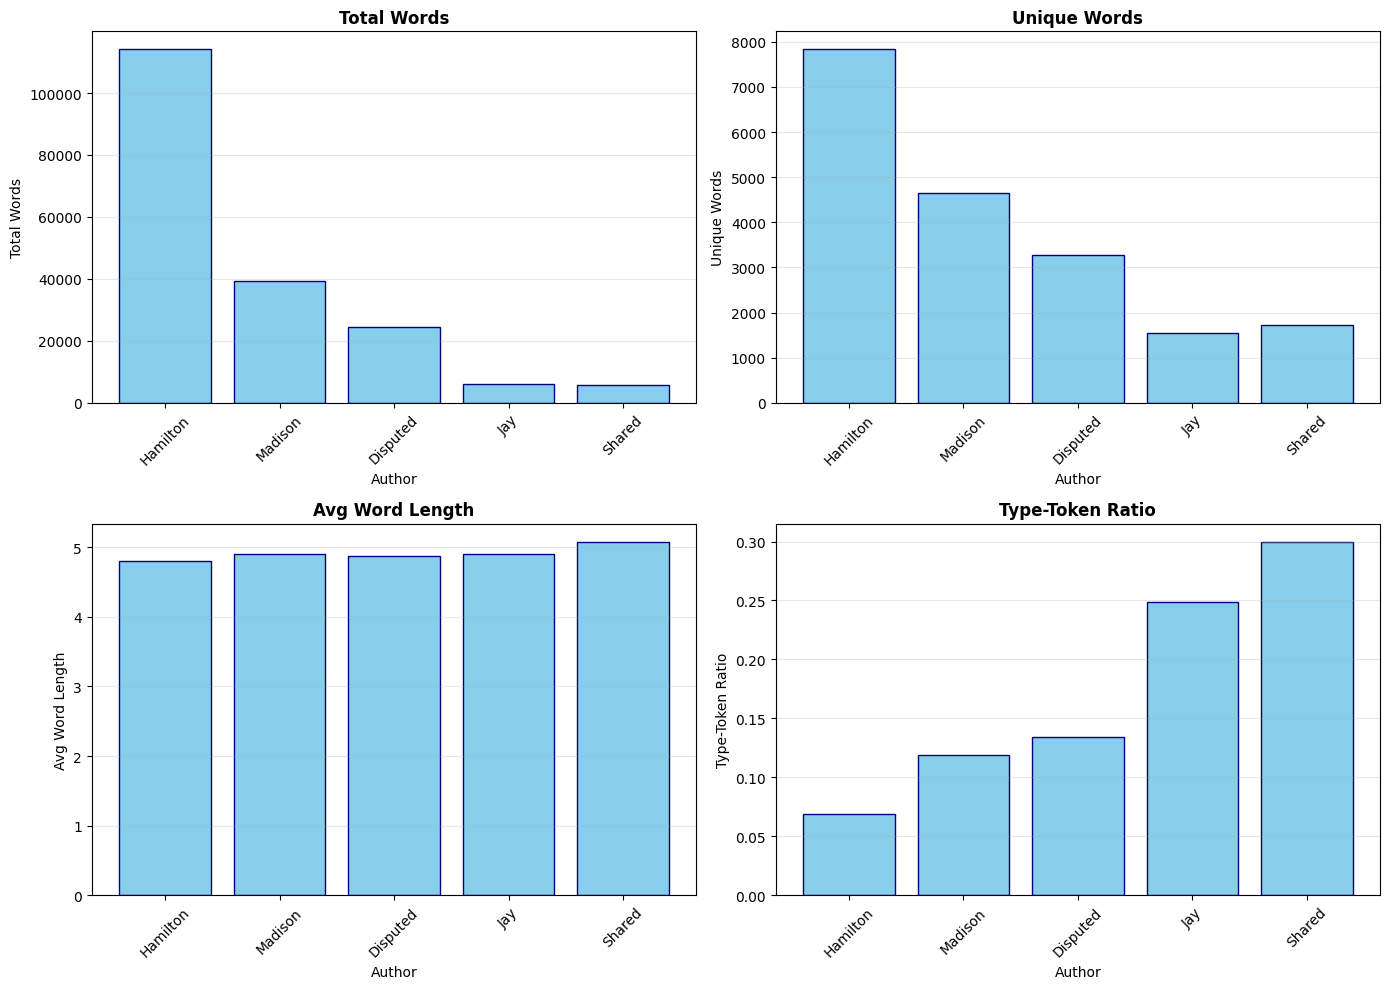

SIMILARITY BETWEEN AUTHORS
Hamilton   vs Madison   : Similarity = 0.998
Hamilton   vs Disputed  : Similarity = 0.999
Hamilton   vs Jay       : Similarity = 0.991
Hamilton   vs Shared    : Similarity = 0.983
Madison    vs Disputed  : Similarity = 0.999
Madison    vs Jay       : Similarity = 0.993
Madison    vs Shared    : Similarity = 0.992
Disputed   vs Jay       : Similarity = 0.993
Disputed   vs Shared    : Similarity = 0.988
Jay        vs Shared    : Similarity = 0.988
DISPUTED PAPERS ANALYSIS
Disputed papers compared to known authors:
----------------------------------------
   vs Hamilton  : Similarity = 0.999
   vs Madison   : Similarity = 0.999
   vs Jay       : Similarity = 0.993

Most similar to: Hamilton (Similarity = 0.999)


In [ ]:
import os
import nltk
from nltk.tokenize import word_tokenize
import string
import matplotlib.pyplot as plt
from collections import Counter

# Set matplotlib to inline for Jupyter/Colab
get_ipython().run_line_magic('matplotlib', 'inline')

# Download NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')

# Define the papers dictionary
papers = {
    'Madison': [10, 14, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48],
    'Hamilton': [1, 6, 7, 8, 9, 11, 12, 13, 15, 16, 17, 21, 22, 23, 24,
                 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 59, 60,
                 61, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
                 78, 79, 80, 81, 82, 83, 84, 85],
    'Jay': [2, 3, 4, 5],
    'Shared': [18, 19, 20],
    'Disputed': [49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 62, 63],
    'TestCase': [64]
}

# Function to read files from current directory
def read_files_into_string(filenames):
    strings = []
    for filename in filenames:
        filepath = f'federalist_{filename}.txt'
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                strings.append(f.read())
            print(f"Loaded: federalist_{filename}.txt")
        except FileNotFoundError:
            print(f"Warning: {filepath} not found. Skipping...")
        except UnicodeDecodeError:
            with open(filepath, 'r', encoding='latin-1') as f:
                strings.append(f.read())
            print(f"Loaded (latin-1): federalist_{filename}.txt")
    return '\n'.join(strings)

# Read all files
print("Loading files...")
federalist_by_author = {}
for author, files in papers.items():
    print(f"\nLoading {author} papers...")
    federalist_by_author[author] = read_files_into_string(files)
    char_count = len(federalist_by_author[author])
    print(f"   -> {char_count:,} characters loaded")


# Tokenize and analyze function
def tokenize_and_filter(text):
    """Tokenize text and remove punctuation"""
    if not text or text.strip() == '':
        return []
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha()]
    return tokens

# Create tokenized versions
print("TOKENIZING TEXTS")
federalist_by_author_tokens = {}
for author, text in federalist_by_author.items():
    tokens = tokenize_and_filter(text)
    federalist_by_author_tokens[author] = tokens
    print(f"{author:12s}: {len(tokens):,} tokens")

# Analyze word length distribution with error handling
print("WORD LENGTH DISTRIBUTIONS")

for author, tokens in federalist_by_author_tokens.items():
    if not tokens:
        print(f"\n{author}: No tokens to analyze!")
        continue

    print(f"\nAnalyzing {author}...")

    word_lengths = [len(token) for token in tokens]
    length_counts = Counter(word_lengths)

    print(f"   Total words: {len(tokens):,}")
    print(f"   Average word length: {sum(word_lengths)/len(tokens):.2f}")
    print(f"   Most common length: {max(length_counts, key=length_counts.get)}")

# Define authors to analyze (including Disputed and Shared)
authors = ("Hamilton", "Madison", "Disputed", "Jay", "Shared")

# Transform the authors' corpora into lists of word tokens
federalist_by_author_tokens_nltk = {}
federalist_by_author_length_distributions = {}

for author in authors:
    print(f"\nProcessing {author}...")

    # Get the text for this author
    text = federalist_by_author[author]

    # Check if text exists
    if not text or text.strip() == '':
        print(f"   No text found for {author}")
        continue

    # Tokenize the text
    tokens = nltk.word_tokenize(text)

    # Filter out punctuation (keep only alphabetic tokens)
    filtered_tokens = [token for token in tokens if any(c.isalpha() for c in token)]
    federalist_by_author_tokens_nltk[author] = filtered_tokens

    print(f"   Total tokens: {len(tokens):,}")
    print(f"   Alphabetic tokens: {len(filtered_tokens):,}")

    # Get a distribution of token lengths
    token_lengths = [len(token) for token in filtered_tokens]
    federalist_by_author_length_distributions[author] = nltk.FreqDist(token_lengths)

    # Plot the distribution
    if token_lengths:
        plt.figure(figsize=(10, 6))
        federalist_by_author_length_distributions[author].plot(15, title=f'Word Length Distribution - {author}')
        plt.show()
    else:
        print(f"   No tokens to plot for {author}")

print("COMPARISON: All Authors Together")

plt.figure(figsize=(14, 8))

colors = ['blue', 'green', 'red', 'orange', 'purple']
markers = ['o', 's', '^', 'D', 'v']
styles = ['-', '--', '-.', ':', '-']

for idx, author in enumerate(authors):
    if author not in federalist_by_author_length_distributions:
        continue

    dist = federalist_by_author_length_distributions[author]

    # Get lengths 1-20
    lengths = range(1, 21)
    counts = [dist.get(l, 0) for l in lengths]

    # Convert to percentages
    total = sum(counts)
    if total > 0:
        percentages = [c/total*100 for c in counts]
        plt.plot(lengths, percentages,
                marker=markers[idx % len(markers)],
                color=colors[idx % len(colors)],
                linestyle=styles[idx % len(styles)],
                label=author,
                linewidth=2,
                markersize=8)

plt.title('Word Length Distribution Comparison (All Authors Including Disputed and Shared)',
          fontsize=14, fontweight='bold')
plt.xlabel('Word Length', fontsize=12)
plt.ylabel('Percentage of Words (%)', fontsize=12)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.xticks(range(1, 21))
plt.tight_layout()
plt.show()

print("STATISTICAL SUMMARY")

# Create summary data
summary_data = []

for author in authors:
    if author not in federalist_by_author_tokens_nltk:
        continue

    tokens = federalist_by_author_tokens_nltk[author]
    if not tokens:
        continue

    token_lengths = [len(token) for token in tokens]
    dist = federalist_by_author_length_distributions[author]

    total_words = len(tokens)
    unique_words = len(set(tokens))
    avg_length = sum(token_lengths) / total_words if total_words > 0 else 0
    most_common_length = max(dist.items(), key=lambda x: x[1])[0] if dist else 0
    ttr = unique_words / total_words if total_words > 0 else 0

    summary_data.append({
        'Author': author,
        'Total Words': total_words,
        'Unique Words': unique_words,
        'Avg Word Length': round(avg_length, 2),
        'Most Common Length': most_common_length,
        'Type-Token Ratio': round(ttr, 3)
    })

# Display summary
for data in summary_data:
    print(f"\n{data['Author']}:")
    print(f"   Total Words: {data['Total Words']:,}")
    print(f"   Unique Words: {data['Unique Words']:,}")
    print(f"   Avg Word Length: {data['Avg Word Length']}")
    print(f"   Most Common Length: {data['Most Common Length']}")
    print(f"   Type-Token Ratio: {data['Type-Token Ratio']}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

stats_to_plot = ['Total Words', 'Unique Words', 'Avg Word Length', 'Type-Token Ratio']
stat_values = {stat: [] for stat in stats_to_plot}
author_names = []

for data in summary_data:
    author_names.append(data['Author'])
    for stat in stats_to_plot:
        stat_values[stat].append(data[stat])

for idx, stat in enumerate(stats_to_plot):
    if idx < len(axes):
        ax = axes[idx]
        ax.bar(author_names, stat_values[stat], color='skyblue', edgecolor='navy')
        ax.set_title(stat, fontsize=12, fontweight='bold')
        ax.set_xlabel('Author')
        ax.set_ylabel(stat)
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("SIMILARITY BETWEEN AUTHORS")

from scipy.spatial.distance import cosine

# Create vectors for each author (lengths 1-20)
author_vectors = {}
for author in authors:
    if author in federalist_by_author_length_distributions:
        dist = federalist_by_author_length_distributions[author]
        vector = [dist.get(l, 0) for l in range(1, 21)]
        total = sum(vector)
        if total > 0:
            author_vectors[author] = [v/total for v in vector]

# Compare authors
author_list = list(author_vectors.keys())
for i in range(len(author_list)):
    for j in range(i+1, len(author_list)):
        author1 = author_list[i]
        author2 = author_list[j]
        similarity = 1 - cosine(author_vectors[author1], author_vectors[author2])
        print(f"{author1:10s} vs {author2:10s}: Similarity = {similarity:.3f}")

print("DISPUTED PAPERS ANALYSIS")

if 'Disputed' in author_vectors:
    disputed_vector = author_vectors['Disputed']
    print("Disputed papers compared to known authors:")
    print("-" * 40)

    for author in ['Hamilton', 'Madison', 'Jay']:
        if author in author_vectors:
            similarity = 1 - cosine(disputed_vector, author_vectors[author])
            print(f"   vs {author:10s}: Similarity = {similarity:.3f}")

    # Find most similar author
    most_similar = max(
        [(author, 1 - cosine(disputed_vector, author_vectors[author]))
         for author in ['Hamilton', 'Madison', 'Jay']
         if author in author_vectors],
        key=lambda x: x[1]
    )
    print(f"\nMost similar to: {most_similar[0]} (Similarity = {most_similar[1]:.3f})")
else:
    print("Disputed papers not found in analysis")